
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_07_abc_modelo_v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7: ABC del aprendizaje de máquina 

## 1. Entendimiento de los datos

El primer paso consiste en comprender el origen y la naturaleza de los datos. Es fundamental identificar la fuente (por ejemplo, si provienen de un censo, sensores o registros operacionales), así como la unidad de observación, es decir, qué representa cada fila: una persona, un distrito, una vivienda, entre otros. 

También es importante reconocer el tipo de variables presentes en el conjunto de datos, distinguiendo entre variables numéricas, categóricas, espaciales o temporales. En esencia, la pregunta clave en esta etapa es: ¿qué representa físicamente cada observación?


## 2. Calidad de datos (Data Quality)

Una vez entendido el dataset, se debe evaluar su calidad. Esto implica analizar la presencia de valores faltantes y determinar si su ausencia es aleatoria o responde a algún patrón estructural. Asimismo, es necesario examinar los valores atípicos (outliers), diferenciando entre posibles errores de medición y fenómenos reales del sistema.

Adicionalmente, se debe verificar la consistencia de los datos, asegurando que las unidades sean correctas y que los valores se encuentren dentro de rangos razonables.


## 3. Análisis exploratorio (EDA)

El análisis exploratorio permite obtener una primera comprensión de la estructura del dataset. En esta fase se estudian las distribuciones de las variables mediante histogramas o funciones de densidad, lo que permite identificar asimetrías, concentraciones o comportamientos anómalos.

También se analizan las relaciones entre variables, por ejemplo, mediante correlaciones o gráficos de dispersión. Finalmente, es útil examinar la geometría del conjunto de datos, identificando posibles agrupaciones (clusters) o patrones espaciales como gradientes.

## 5. Feature Engineering

En esta etapa se transforman las variables originales para construir representaciones más informativas del problema. Esto puede implicar la creación de nuevas variables derivadas o la aplicación de transformaciones que faciliten el modelado.

Por ejemplo, es común definir medidas de densidad como:

$$
\text{rooms\_per\_household} = \frac{\text{total\_rooms}}{\text{households}}
$$

o variables como el número de personas por hogar. También pueden aplicarse transformaciones como el logaritmo de la variable objetivo:

$$
\log(y)
$$


## 6. Partición del dataset

Para evaluar correctamente el desempeño de los modelos, es necesario dividir el conjunto de datos en subconjuntos de entrenamiento, validación y prueba. Esta separación permite evitar el sobreajuste y obtener estimaciones realistas del rendimiento.

Es importante enfatizar que el conjunto de prueba debe permanecer completamente aislado durante el desarrollo del modelo.


## 7. Modelado

En función del problema planteado, se selecciona un modelo adecuado, como regresión lineal, árboles de decisión, métodos de ensamble o redes neuronales. En términos generales, el objetivo es aproximar una relación funcional entre las variables de entrada y la variable objetivo:

$$
y = f_\theta(X)
$$


## 8. Entrenamiento

El entrenamiento consiste en ajustar los parámetros del modelo mediante la minimización de una función de costo. Un ejemplo común en problemas de regresión es el error cuadrático medio:

$$
\mathcal{L}(\theta) = \frac{1}{n} \sum (y_i - \hat{y}_i)^2
$$

Este proceso se realiza mediante algoritmos de optimización, como el gradiente descendente.


## 9. Evaluación

Una vez entrenado el modelo, se evalúa su desempeño utilizando métricas adecuadas como el error absoluto medio (MAE), el error cuadrático medio (RMSE) o el coeficiente de determinación (R²):

$$
\text{MAE} = \frac{1}{n}\sum |y_i - \hat{y}_i|
$$

Es fundamental que esta evaluación se realice sobre datos no utilizados durante el entrenamiento.


## 10. Interpretabilidad

Además del rendimiento, es importante comprender cómo el modelo utiliza las variables. Esto incluye analizar la importancia de las variables y la sensibilidad de las predicciones frente a cambios en las entradas.


## 11. Incertidumbre

Todo modelo presenta cierto grado de incertidumbre, por lo que es necesario cuantificarla. Esto puede hacerse mediante intervalos de confianza, técnicas de remuestreo como bootstrap o analizando la variabilidad de las predicciones.


## 12. Validación del modelo

La validación busca asegurar que el modelo generaliza adecuadamente a nuevos datos. Esto implica evaluar su robustez frente a diferentes particiones o condiciones.



## 14. Comunicación

Los resultados deben presentarse de forma clara y coherente, apoyándose en visualizaciones adecuadas y evitando interpretaciones exageradas. La comunicación es clave para que el análisis tenga impacto.

## 15. Deployment

En contextos aplicados, el modelo puede ser desplegado en producción, por ejemplo, mediante una API o procesos batch. Esto permite su uso en sistemas reales.

## 16. Monitoreo y drift

Una vez en producción, es necesario monitorear el comportamiento del modelo, especialmente posibles cambios en la distribución de los datos:

$$
P_{\text{train}}(X) \neq P_{\text{prod}}(X)
$$

Estos cambios pueden afectar el desempeño del modelo con el tiempo.

## 17. Reproducibilidad

Finalmente, todo el proceso debe ser reproducible. Esto implica mantener un adecuado versionado de los datos, código limpio, control de semillas aleatorias y registro de experimentos.

# Problema

El dataset de viviendas de California corresponde a un conjunto de datos basado en el censo de 1990, que contiene información sobre los precios medios de las viviendas junto con diversas características demográficas y estructurales de los distritos en el estado de California.

A continuación, se describen las variables incluidas en el dataset:

- **longitude**: longitud del centroide del distrito (en grados). Indica la posición geográfica en el eje este-oeste.

- **latitude**: latitud del centroide del distrito (en grados). Indica la posición geográfica en el eje norte-sur.

- **housing_median_age**: edad media de las viviendas en el distrito (en años). Proporciona una aproximación al estado y antigüedad de las construcciones.

- **total_rooms**: número total de habitaciones en el distrito, sin distinción de tipo. Refleja la capacidad habitacional agregada.

- **total_bedrooms**: número total de dormitorios en el distrito. Representa los espacios destinados al descanso dentro de las viviendas.

- **population**: número total de habitantes del distrito. Permite inferir la densidad poblacional y la presión sobre la vivienda.

- **households**: número de hogares en el distrito. Un hogar corresponde a un grupo de personas que habitan una misma vivienda; esta variable describe la estructura residencial.

- **median_income**: ingreso medio por hogar (expresado en miles de dólares, $10^3$ USD). Indica el nivel socioeconómico de los residentes.

- **median_house_value**: valor medio de las viviendas (expresado en cientos de miles de dólares, $10^5$ USD). Esta es la **variable objetivo** del problema, ya que representa el precio promedio de las propiedades en cada distrito.

# 1.0 Análisis del data frame

1. Leer el data frame en formato csv en la dirección https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

RAW_DATA_URL = "https://raw.githubusercontent.com/hernansalinas/Curso_aprendizaje_estadistico/main/datasets/Sesion_07_housing.csv"

# Punto 1
df_raw = pd.read_csv(RAW_DATA_URL)
df_raw.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


2. Entender  el estado de los datos, para ello puedo emplear los comandos básicos del pandas

  ```python
  df_raw.info()
  df_raw.describe()
  df_raw.isnull().sum()
  df_raw.isna().sum()
```
Estos dos últimos son equivalentes.

In [3]:
# Punto 2
print(df_raw.info())
print("="*50)
print(df_raw.describe())

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB
None
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.5

Solo hay datos nulos en total_bedrooms y es un porcentaje despreciablemente bajo (Indica que el dataset ya fue limpiado, esto no es lo normal).La mayoría de las columnas son numéricas (float64) y solo hay una columna tipo String: ocean_proximity.

Lo único que me parece extraño es que columnas como total_bedrooms o total_rooms tienen valores extraños (si no interpreto mal) de máximos. El máximo de total_rooms es 39320 y el de total_bedrooms es 6445.

No voy a borrar lo que dije, pero creo que ya entiendo. Esto se explica si entendemos que cada fila del dataset es algo así como un "distrito" o zona del estado, NO ES UNA SOLA CASA!

3. ¿Cuántas variables tiene el dataset y de qué tipo son?

In [4]:
# Punto 3
df_shape = df_raw.shape
print(f"El dataset tiene {df_shape[0]} filas y {df_shape[1]} columnas.")

El dataset tiene 20640 filas y 10 columnas.


Lo anterior es optimista. Más de 20000 datos que cada uno representa un distrito del estado de california (en realidad, un bloque de viviendas) y solo total_bedrooms tiene datos nulos en las filas.

4. ¿Existen valores faltantes? ¿En qué variables estan? ¿cuántos son?

In [5]:
print(df_raw.isnull().sum())
total_bedrooms_null_percentage = df_raw.isnull().sum()['total_bedrooms'] / df_shape[0] * 100
print(f"\nEl porcentaje de valores nulos en 'total_bedrooms' es: {total_bedrooms_null_percentage:.4f}%")

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

El porcentaje de valores nulos en 'total_bedrooms' es: 1.0029%


5. Determinar los elementos únicos dentro de la columna ocean_proximity.

In [6]:
df_raw['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

6. Para las columnas

```python
cols = ["housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]
```

Determinar el promedio de cada una de las columnas asociado a cada elementos unico de ocean_proximity, intenta con la operación groupby.

In [7]:
cols = ["housing_median_age",	"total_rooms",	"total_bedrooms",	"population",	"households",	"median_income",	"median_house_value"]
df_raw.groupby('ocean_proximity')[cols].mean()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
ocean_proximity,,,,,,,
<1H OCEAN,29.279225,2628.343586,546.539185,1520.290499,517.744965,4.230682,240084.285464
INLAND,24.271867,2717.742787,533.881619,1391.046252,477.447565,3.208996,124805.392001
ISLAND,42.400000,1574.600000,420.400000,668.000000,276.600000,2.744420,380440.000000
NEAR BAY,37.730131,2493.589520,514.182819,1230.317467,488.616157,4.172885,259212.311790
NEAR OCEAN,29.347254,2583.700903,538.615677,1354.008653,501.244545,4.005785,249433.977427


7. Construye un histograma para cada columna, puede emplear la libreria de seaborn.

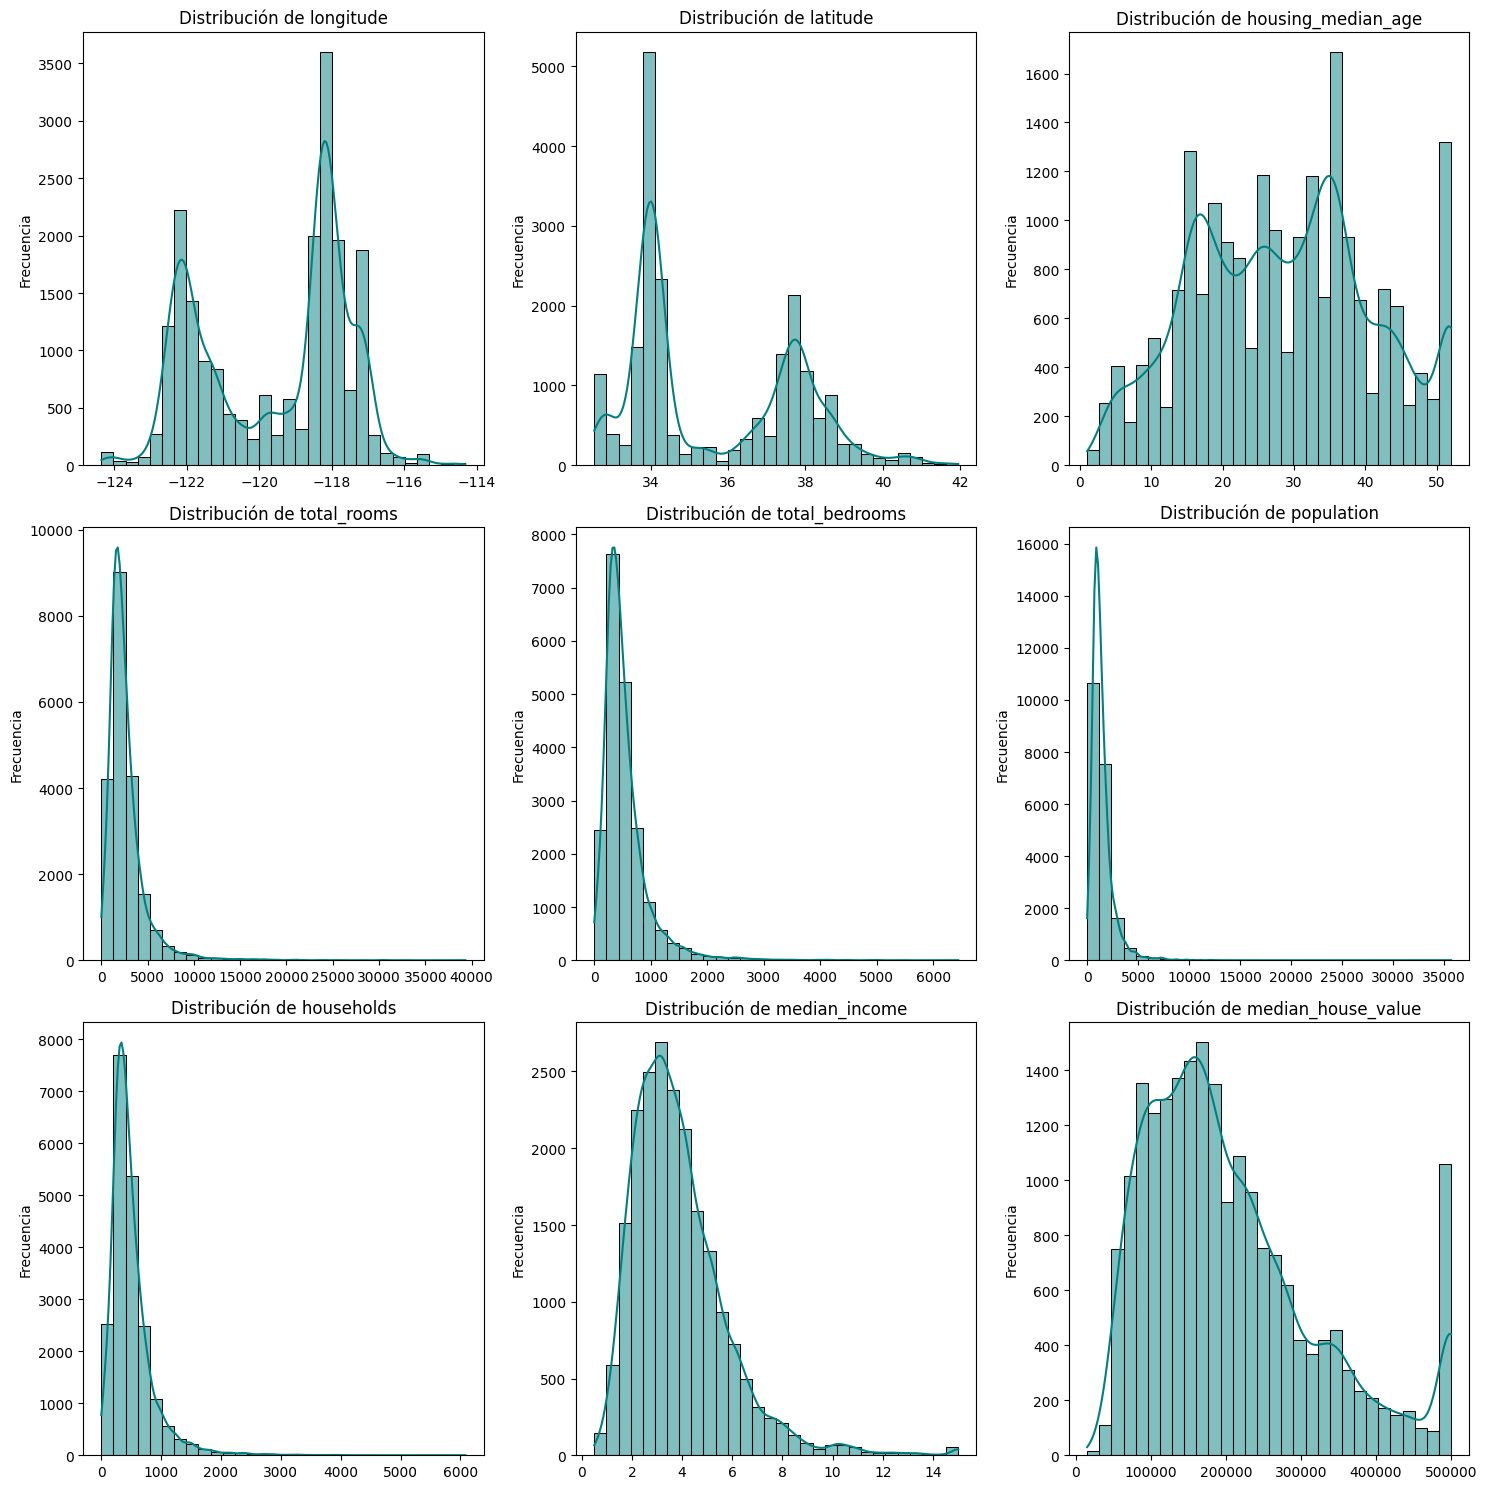

In [8]:
# Seleccionamos únicamente las columnas numéricas para evitar errores con variables categóricas
num_cols = df_raw.select_dtypes(include=['float64', 'int64']).columns

# Configuramos la figura y una cuadrícula de 3x3
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15, 15))

# Aplanamos la matriz de ejes (de 2D a 1D) para poder iterar sobre ella fácilmente
axes = axes.flatten()

# Iteramos sobre cada columna numérica y su índice
for i, col in enumerate(num_cols):
    # Generamos el histograma en el eje correspondiente (ax=axes[i])
    # kde=True superpone la función de densidad de probabilidad estimada
    sns.histplot(data=df_raw, x=col, ax=axes[i], kde=True, bins=30, color='teal')
    
    # Mejoramos la presentación de cada subgráfico
    axes[i].set_title(f'Distribución de {col}', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Frecuencia')

# tight_layout ajusta automáticamente los parámetros de la subtrama para que encajen bien en el área
plt.tight_layout()
plt.show()

### [Diagrama de caja](https://en.wikipedia.org/wiki/Box_plot)


### Diagrama de caja

![box](https://upload.wikimedia.org/wikipedia/commons/e/ed/Box_Plot_Picture.png)



### Interpretación de un diagrama de caja

- Desde el minimo al valor más bajo de la caja: primer cuartil, 25% de los datos
- Desde el valor más bajo de la caja hasta la mediana: segundo cuartil, 25% de los datos
- Desde la mediana hasta el valor mas alto de la caja : tercer cuartil, 25% de los datos
- Desde el valor mas alto de la caja hasta el máximo: Cuarto  cuartil, 25% de los datos


El rango intercuartil $IQR = Q_3-Q_1$ permite definir que datos pueden ser atípicos, basado en los siguientes limites:

$Max = Q3 + 1.5IQR$

$Min = Q1 - 1.5IQR$



El cuartil puede ser determinado como sigue:

Para calcular los cuartiles de una lista de números:

- Ordenar los números de menor a mayor.
- Calcular la posición de cada cuartil usando la fórmula: Q = a (N+1) / 4, donde Q es la posición del cuartil, a es el número del cuartil (1, 2 o 3), y N es el número total de datos.
- Si la posición del cuartil es un número entero, el valor del cuartil es el dato que está en esa posición.
- Si la posición del cuartil es un número decimal, el valor del cuartil se interpola usando la fórmula: Q = x + d (y - x), donde Q es el valor del cuartil, x es el dato anterior a la posición del cuartil, y es el dato posterior a la posición del cuartil, y d es la parte decimal de la posición del cuartil.


Veamos un ejemplo:



In [9]:
T = np.array([52, 57, 57, 58, 63, 66, 66, 67, 67, 68, 69, 70, 70, 70, 70, 72, 73, 75, 75, 76, 76, 78, 79, 89])
Tsort = np.sort(T)
print(len(T))
print(f"T sort:{Tsort}")
len(T)/4

24
T sort:[52 57 57 58 63 66 66 67 67 68 69 70 70 70 70 72 73 75 75 76 76 78 79 89]


6.0

88.5
52.5


{'whiskers': [<matplotlib.lines.Line2D at 0x7f8afef1d010>,
 'caps': [<matplotlib.lines.Line2D at 0x7f8afef1d2b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f8afef1cec0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f8afef1d550>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f8afef1d6a0>],
 'means': []}

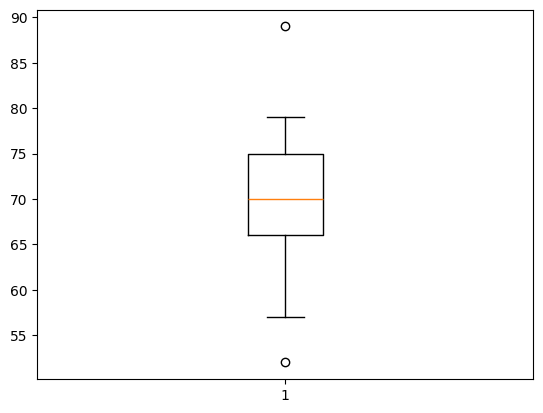

In [10]:

IQR=9
max_ = 75 + 1.5*IQR
min_ = 66 - 1.5*IQR
print(max_)
print(min_)
plt.boxplot(T)

8. Empleando el siguiente código realiza el gráfico boxplot,
```python
#draw boxplot
df_raw.boxplot(column="median_house_value", by='ocean_proximity', sym = 'k.', figsize=(18,6))
#set title
plt.title('Boxplot for comparing price per living space for each city')
plt.show()
```

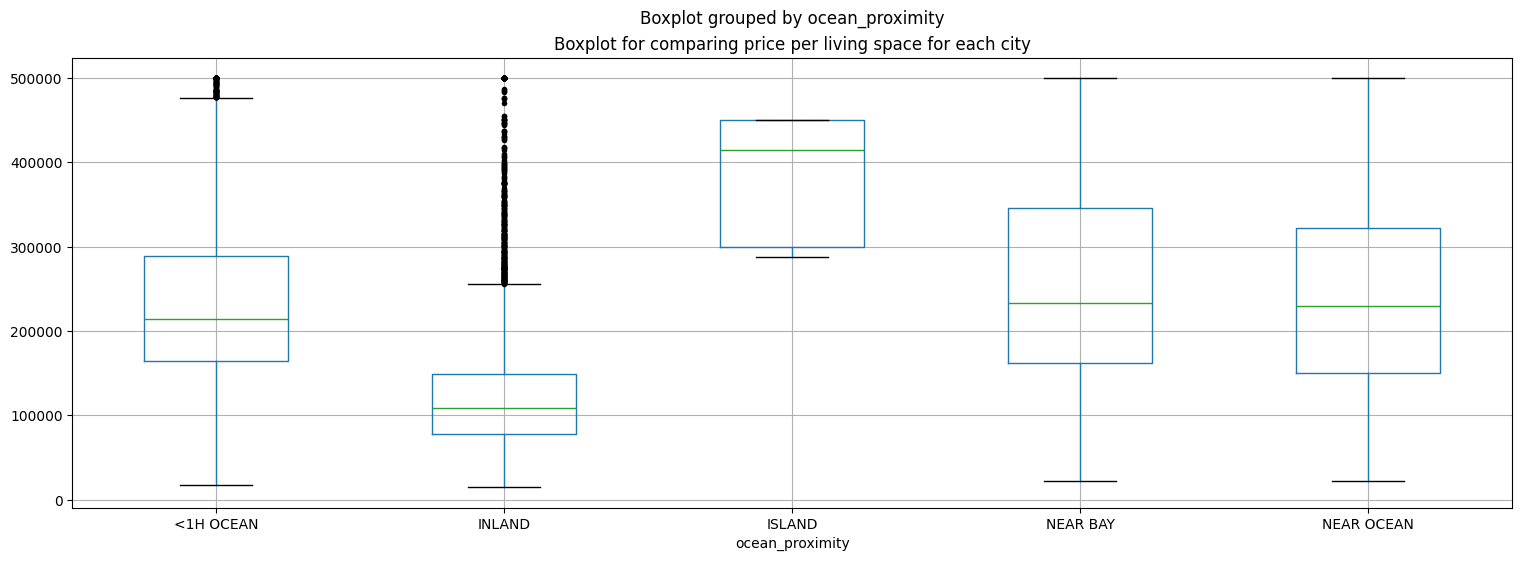

In [11]:
# Punto 8
df_raw.boxplot(column="median_house_value", by='ocean_proximity', sym = 'k.', figsize=(18,6))
#set title
plt.title('Boxplot for comparing price per living space for each city')
plt.show()

Increíble la cantidad de Outliers que tienen los datos agrupados en "INLAND", demostrando la inestabilidad de los precios en el tierra continental. Tal vez pueda explicarse explorando las otras columnas.

9. Determina la matrix de correlación.

### [Matrix de correlación](https://en.wikipedia.org/wiki/Correlation)

¿Como se determina la matrix de correlación?

![Matrix de correlación](https://upload.wikimedia.org/wikipedia/commons/thumb/d/d4/Correlation_examples2.svg/1920px-Correlation_examples2.svg.png)



```python
corr_matrix = df_raw.corr()
corr_matrix

plt.figure(figsize = (10,6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", center=0)
plt.show()
```

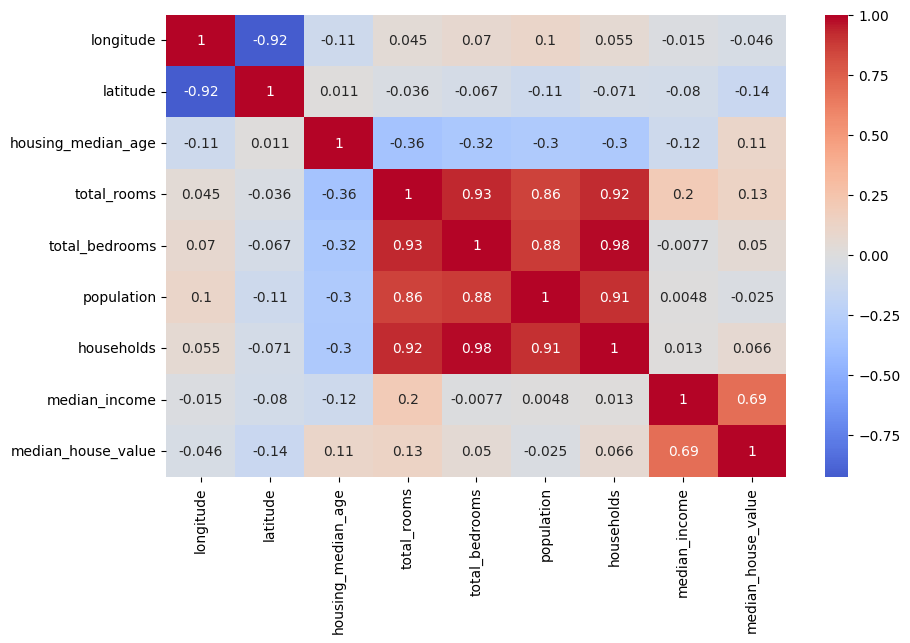

In [14]:
# Punto 9
corr_matrix = df_raw.drop(columns=['ocean_proximity']).corr() # Se debe eliminar ocean_proximity porque es una variable categórica y no se puede incluir en la matriz de correlación.
corr_matrix

plt.figure(figsize = (10,6))
sns.heatmap(corr_matrix, annot = True, cmap = "coolwarm", center=0)
plt.show()

Las variables que son derivadas entre sí tiene sentido que tengan alta correlacion positiva: total_rooms, total_bedrooms.

Por otro lado, tambien tiene sentido la correlación: "Mayor numero de habitaciones/casas -> Mayor número de personas (population)"

10. con las columnas, realiza un grafico pairplot empleando seaborn  de python.
```python
cols = ["median_house_value", "median_income", "total_rooms","housing_median_age"]
```

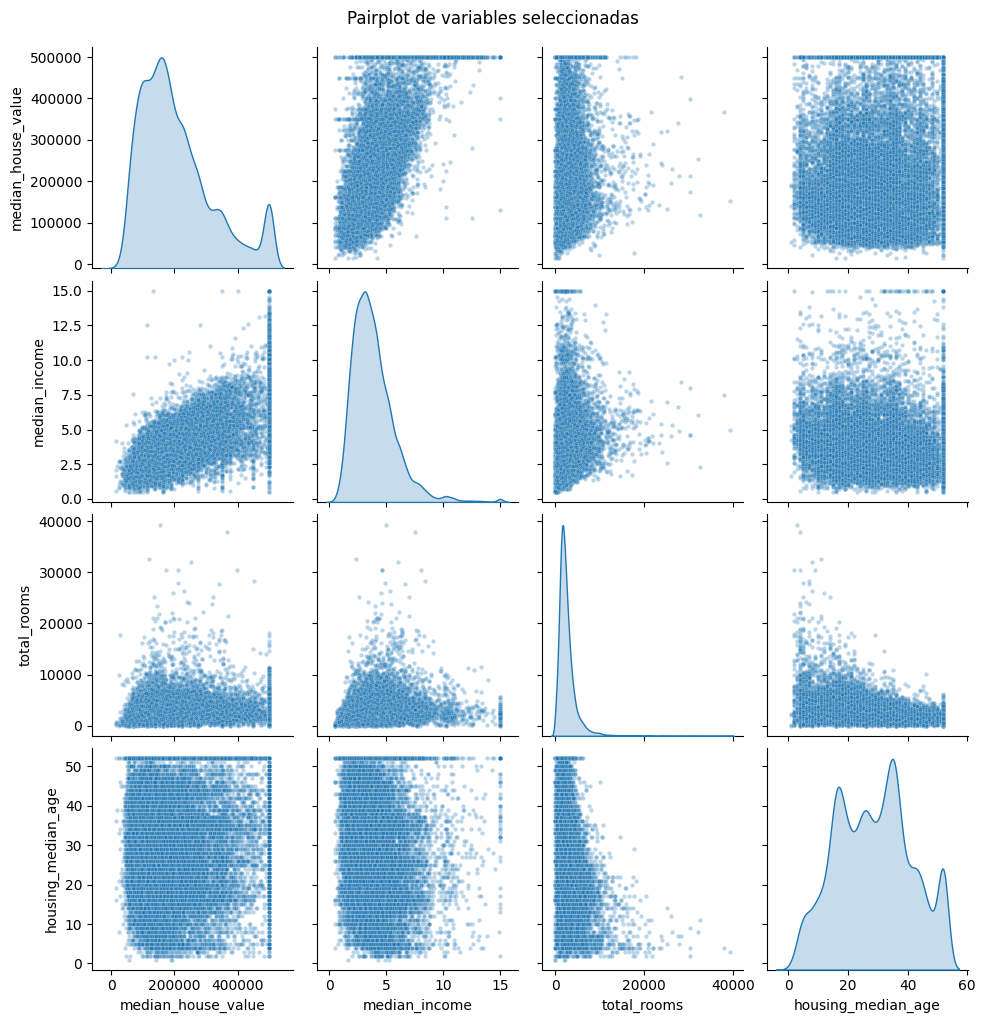

In [15]:
# Punto 10
cols = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

g = sns.pairplot(df_raw[cols], diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
g.fig.suptitle("Pairplot de variables seleccionadas", y=1.02)
plt.show()

La relación más visible es entre `median_income` y `median_house_value`: a mayor ingreso del distrito, mayor valor de las viviendas. También se nota que `median_house_value` tiene una distribución truncada en $500 001 — un artefacto del censo que impuso ese tope máximo, lo que genera la línea horizontal que aparece en los scatter plots.

11. Realiza un scatter plot con la libreria sea born de python, el color del grafico puede ser empleado con la columna median_house_value

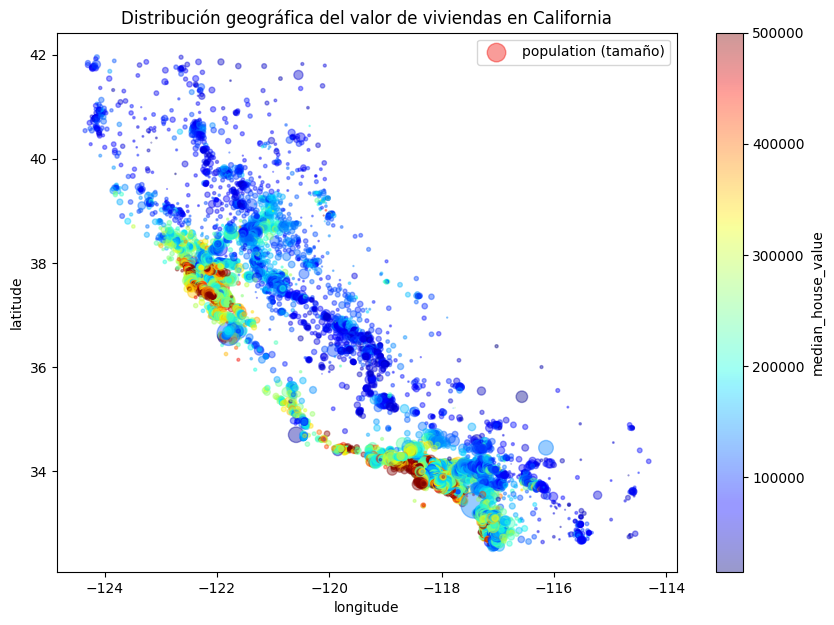

In [16]:
df_raw.plot(
    kind="scatter",
    x="longitude",
    y="latitude",
    alpha=0.4,
    figsize=(10, 7),
    c="median_house_value",
    cmap="jet",
    colorbar=True,
    s=df_raw["population"] / 100,
    label="population (tamaño)",
)
plt.title("Distribución geográfica del valor de viviendas en California")
plt.legend()
plt.show()

Longitude y latitude dan la posición geográfica de cada distrito. El tamaño de cada punto representa la población, el color el valor de la vivienda.

Sería interesante sobreponerlo a un mapa geográfico de la región para tambien ver como afecta 'ocean_proximity'.

# 2.0 Preparacion del data frame

12.
¿Las siguiente linea es adecuada para separar el dataframe en datos de entrenamiento de test?, ¿que pasa en la división de los datos?


```python
from sklearn.model_selection import train_test_split

# ¿Es significativa la muestra que se esta considerando?
train_set, test_set \
  = train_test_split(df_raw, test_size = 0.2, random_state = 42)

print(len(train_set))
print(len(test_set))

```

In [18]:
from sklearn.model_selection import train_test_split

# ¿Es significativa la muestra que se esta considerando?
train_set, test_set \
  = train_test_split(df_raw, test_size = 0.2, random_state = 42)

print(len(train_set))
print(len(test_set))

16512
4128


Esta división es puramente aleatoria. Con 20640 filas suele funcionar razonablemente, pero NO garantiza representatividad por estrato de ingreso. Si median_income es sesgada, algunos rangos de ingreso quedan sub- o sobre-representados en train/test.

13. La siguiente división puede ser realizada  basada en la experticie de lo que se esta analizando, y sobre ello se debe tomar una muestra significativa. Una posible solución al problema puede ser el siguiente:

```python
df_raw["income_cat"] = pd.cut(df_raw["median_income"],
                               bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                               labels=[1, 2, 3, 4, 5])


df_raw.income_cat.hist()


```

La forma automatica de realizar la división puede ser la siguiente:

```python
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits = 1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df_raw, df_raw["income_cat"]):
  strat_train_set = df_raw.loc[train_index]
  strat_test_set = df_raw.loc[test_index]

```


Analiza las siguiente lineas de código y saca conclusiones referente a las proporciones del dataset.

```python
df_raw["income_cat"].value_counts() / len(df_raw)

strat_train_set["income_cat"].value_counts() / len(strat_train_set)

strat_test_set["income_cat"].value_counts() / len(strat_test_set)


train_set, test_set \
  = train_test_split(df_raw, test_size = 0.2, random_state = 7)

train_set["income_cat"].value_counts() / len(train_set)
```

un comparativo general puede ser estructurado de la siguente forma, analiza  los errores:

```python
def income_cat_proportions(data):
    return data["income_cat"].value_counts() / len(data)

train_set, test_set = train_test_split(df_raw, test_size = 0.2, random_state = 42)

compare_props = pd.DataFrame({
    "Overall": income_cat_proportions(df_raw),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random": income_cat_proportions(test_set),
}).sort_index()
compare_props["Rand. %error"] =abs( 100 * compare_props["Random"] / compare_props["Overall"] - 100)
compare_props["Strat. %error"] =abs( 100 * compare_props["Stratified"] / compare_props["Overall"] - 100)

Puedes agregar nuevas variables al dataframe para el análisis, por ejemplo:
```python
df_train["rooms_per_household"] = df_train["total_rooms"]/df_train["households"]
df_train["bedrooms_per_room"] = df_train["total_bedrooms"]/df_train["total_rooms"]
df_train["population_per_household"]=df_train["population"]/df_train["households"]
```




# Limpieza de datos

Lo que sigue son códigos que pueden servir para limpiar los datos.

```python

df_raw.isnull().sum()


#df_train.dropna(subset=["total_bedrooms"]) #Eliminar los nan
#df_train.drop("total_bedrooms", axis=1)  # Eliminar la columna
median = df_train["total_bedrooms"].median()
q=df_train["total_bedrooms"].fillna(median).copy()


q=pd.DataFrame(q)

q.isnull().sum()

```

##imputer

Forma automática para tratar los datos (Asegurate de trabajar con las columnas numéricas):


```python
from sklearn.impute import SimpleImputer
#imputer = Imputer(strategy="median")

df_train_num = df_train.drop("ocean_proximity", axis=1)

imp_mean = SimpleImputer( strategy='mean')

imp_mean.fit(df_train_num)

imp_mean.statistics_
```

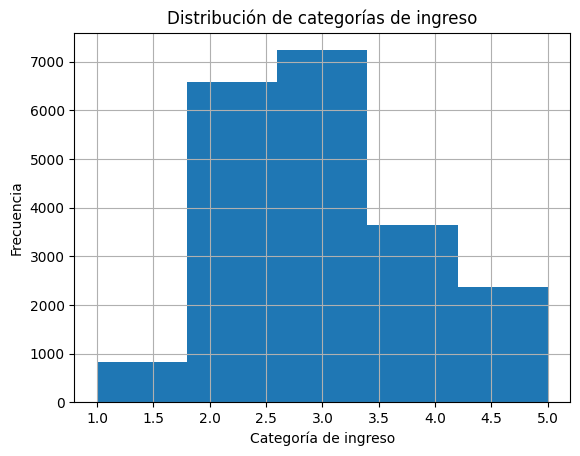

Proporciones por estrato de ingreso:
             Overall  Stratified    Random  Rand. %error  Strat. %error
income_cat                                                             
1           0.039826    0.039971  0.040213      0.973236       0.364964
2           0.318847    0.318798  0.324370      1.732260       0.015195
3           0.350581    0.350533  0.358527      2.266446       0.013820
4           0.176308    0.176357  0.167393      5.056334       0.027480
5           0.114438    0.114341  0.109496      4.318374       0.084674

Imputer ajustado. Columnas con sus medias de entrenamiento:
longitude                   -119.575635
latitude                      35.639314
housing_median_age            28.653404
total_rooms                 2622.539789
total_bedrooms               534.914639
population                  1419.687379
households                   497.011810
median_income                  3.875884
rooms_per_household            5.440406
bedrooms_per_room              0.21287

In [19]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer

# --- 1. Categorizar median_income en 5 estratos ---
df_raw["income_cat"] = pd.cut(
    df_raw["median_income"],
    bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
    labels=[1, 2, 3, 4, 5],
)

df_raw["income_cat"].hist(bins=5)
plt.title("Distribución de categorías de ingreso")
plt.xlabel("Categoría de ingreso")
plt.ylabel("Frecuencia")
plt.show()

# --- 2. Split estratificado por income_cat ---
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_idx, test_idx in split.split(df_raw, df_raw["income_cat"]):
    strat_train_set = df_raw.loc[train_idx]
    strat_test_set  = df_raw.loc[test_idx]

# --- 3. Comparar proporciones: estratificado vs aleatorio ---
def income_cat_proportions(data):
    """Calcula la proporción de cada categoría de ingreso en un subconjunto."""
    return data["income_cat"].value_counts() / len(data)

_, test_set_random = train_test_split(df_raw, test_size=0.2, random_state=42)

compare_props = pd.DataFrame({
    "Overall":    income_cat_proportions(df_raw),
    "Stratified": income_cat_proportions(strat_test_set),
    "Random":     income_cat_proportions(test_set_random),
}).sort_index()

compare_props["Rand. %error"]  = abs(100 * compare_props["Random"]     / compare_props["Overall"] - 100)
compare_props["Strat. %error"] = abs(100 * compare_props["Stratified"] / compare_props["Overall"] - 100)

print("Proporciones por estrato de ingreso:")
print(compare_props.to_string())

# --- 4. Feature engineering sobre el conjunto de entrenamiento ---
df_train = strat_train_set.drop(columns=["income_cat"]).copy()

df_train["rooms_per_household"]      = df_train["total_rooms"]    / df_train["households"]
df_train["bedrooms_per_room"]        = df_train["total_bedrooms"] / df_train["total_rooms"]
df_train["population_per_household"] = df_train["population"]     / df_train["households"]

# --- 5. Imputación de valores faltantes (ajuste solo en train → sin data leakage) ---
df_train_num = df_train.drop(columns=["ocean_proximity", "median_house_value"])

imp_mean = SimpleImputer(strategy="mean")
imp_mean.fit(df_train_num)

print("\nImputer ajustado. Columnas con sus medias de entrenamiento:")
print(pd.Series(imp_mean.statistics_, index=df_train_num.columns).to_string())

14. Compara las siguientes variables:
```python
imp_mean.statistics_
df_train_num.median()
```


```python
Constuye la matriz de características:

X = imp_mean.transform(df)
housing_tr = pd.DataFrame(X, columns=df_train_num.columns)
```

In [ ]:
comparison = pd.DataFrame({
    "imputer_mean":   imp_mean.statistics_,
    "dataset_median": df_train_num.median().values,
}, index=df_train_num.columns)

print("Media usada por el imputer vs mediana del dataset de entrenamiento:")
print(comparison.to_string())


# Construir la matriz de features imputada
housing_tr = pd.DataFrame(
    imp_mean.transform(df_train_num),
    columns=df_train_num.columns,
)

print(f"\nForma de housing_tr: {housing_tr.shape}")
print(f"Valores nulos restantes: {housing_tr.isnull().sum().sum()}")

Media usada por el imputer vs mediana del dataset de entrenamiento:
                          imputer_mean  dataset_median
longitude                  -119.575635     -118.510000
latitude                     35.639314       34.260000
housing_median_age           28.653404       29.000000
total_rooms                2622.539789     2119.000000
total_bedrooms              534.914639      433.000000
population                 1419.687379     1164.000000
households                  497.011810      408.000000
median_income                 3.875884        3.541550
rooms_per_household           5.440406        5.232342
bedrooms_per_room             0.212873        0.203027
population_per_household      3.096469        2.817661

La media y la mediana difieren porque columnas como total_rooms o population tienen distribuciones sesgadas a la derecha, donde los outliers elevan la media por encima de la mediana.

Forma de housing_tr: (16512, 11)
Valores nulos restantes: 0


La media y la mediana difieren porque columnas como total_rooms o population tienen distribuciones sesgadas a la derecha, donde los outliers elevan la media por encima de la mediana.

15. ¿Qué realizan las siguientes lineas de código?

```
from sklearn.preprocessing import OneHotEncoder
df_train["ocean_proximity"].unique()
housing_cat=df_train[["ocean_proximity"]]
housing_cat

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)
print(housing_cat_1hot)
print(cat_encoder.categories_)


df_cat_1hot = pd.DataFrame(housing_cat_1hot, columns = cat_encoder.categories_[0])

housing_tr_ = housing_tr.join(df_cat_1hot)
```

In [22]:
from sklearn.preprocessing import OneHotEncoder

housing_cat = df_train[["ocean_proximity"]]

cat_encoder = OneHotEncoder(sparse_output=False)
housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

print("Categorías detectadas:", cat_encoder.categories_[0])
print(f"Shape de housing_cat_1hot: {housing_cat_1hot.shape}")

df_cat_1hot = pd.DataFrame(
    housing_cat_1hot,
    columns=cat_encoder.categories_[0],
)

housing_tr_ = housing_tr.reset_index(drop=True).join(df_cat_1hot.reset_index(drop=True))

print(f"\nForma final de housing_tr_: {housing_tr_.shape}")
print(housing_tr_.head())

Categorías detectadas: ['<1H OCEAN' 'INLAND' 'ISLAND' 'NEAR BAY' 'NEAR OCEAN']
Shape de housing_cat_1hot: (16512, 5)

Forma final de housing_tr_: (16512, 16)
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -121.46     38.52                29.0       3873.0           797.0   
1    -117.23     33.09                 7.0       5320.0           855.0   
2    -119.04     35.37                44.0       1618.0           310.0   
3    -117.13     32.75                24.0       1877.0           519.0   
4    -118.70     34.28                27.0       3536.0           646.0   

   population  households  median_income  rooms_per_household  \
0      2237.0       706.0         2.1736             5.485836   
1      2015.0       768.0         6.3373             6.927083   
2       667.0       300.0         2.8750             5.393333   
3       898.0       483.0         2.2264             3.886128   
4      1837.0       580.0         4.4964             6.096552   



Según entiendo, el OHE convierte los 5 valores únicos de ocean_proximity en 5 columnas binarias. Sin esto, el modelo trataría las categorías como si tuvieran un orden numérico (<1H OCEAN=1 < INLAND=2 < ...), lo cual no tiene sentido semántico.

En otras palabras, cada valor único en 'ocean_proximity' se convierte en una columna independiente con valores booleanos. Luego, a cada fila del dataset se le asigna su valor de 1 en su columna correspondiente. Una misma fila solo podrá tener un valor en 1 a la vez.

16. Las variables pueden ser escaladas como sigue:

```python

cols=["longitude", "latitude",	"housing_median_age",	"total_rooms",\
      "total_bedrooms",	"population",	"households",	"median_income",\
      "<1H OCEAN",	"INLAND",	"ISLAND",	"NEAR BAY", "NEAR OCEAN"]


housing_scale=housing_tr_[cols]
housing_scale


from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaler.fit(housing_scale)

X = scaler.transform(housing_scale)


housing_prepared = pd.DataFrame(X, columns = housing_scale.columns)

```

In [23]:
from sklearn.preprocessing import MinMaxScaler

cols = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households", "median_income",
    "<1H OCEAN", "INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN",
]

housing_scale = housing_tr_[cols]

scaler = MinMaxScaler()
scaler.fit(housing_scale)

housing_prepared = pd.DataFrame(
    scaler.transform(housing_scale),
    columns=housing_scale.columns,
)

print("Rango de valores tras el escalamiento (deben estar todos en [0, 1]):")
print(pd.DataFrame({"min": housing_prepared.min(), "max": housing_prepared.max()}).to_string())
print(f"\nShape final: {housing_prepared.shape}")

Rango de valores tras el escalamiento (deben estar todos en [0, 1]):
                    min  max
longitude           0.0  1.0
latitude            0.0  1.0
housing_median_age  0.0  1.0
total_rooms         0.0  1.0
total_bedrooms      0.0  1.0
population          0.0  1.0
households          0.0  1.0
median_income       0.0  1.0
<1H OCEAN           0.0  1.0
INLAND              0.0  1.0
ISLAND              0.0  1.0
NEAR BAY            0.0  1.0
NEAR OCEAN          0.0  1.0

Shape final: (16512, 13)


Es una normalizacion a TODAS las columnas. Redundante para columnas booleanas despues del OHE.

17. Para todos los pasos anteriores, contruye ordenadamente los pasos limpieza, escalamiento de variables, manejo de texto y atributos categóricos para tener el data frame listo para el análisis. Recuerda dividir el data frame en datos de entrenamiento y de test con la correcta estractificación. Genera dos data frame: housing_train, housing_test, cada una, debe tener las caracteristicas y los datos etiquetados.

    1. ¿que puede concluir respecto al modelo empleado?
    2. ¿El modelo de regresión lineal es valido para lo construido,
    3. ¿qué informacion nos da el score?
    4. ¿Puede ser ajustado a otro modelo?
    5. ¿Como puede autmatizar todo el proceso empleando pipelines?

MAE:  $48,967
RMSE: $66,800
R²:   0.6576


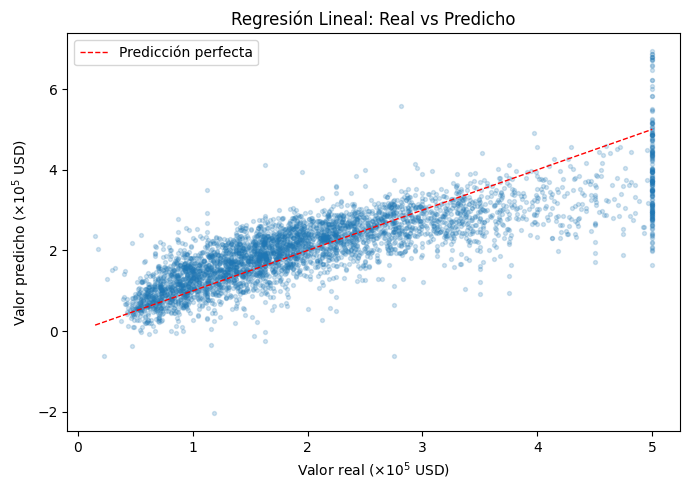

In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

TARGET = "median_house_value"


def add_engineered_features(X):
    """
    Agrega features de densidad derivadas de los conteos brutos del distrito.

    Args:
        X (pd.DataFrame): DataFrame con las columnas originales del dataset.

    Returns:
        pd.DataFrame: Mismo DataFrame con tres columnas adicionales:
            - rooms_per_household: habitaciones por hogar.
            - bedrooms_per_room: proporción de dormitorios sobre total de habitaciones.
            - population_per_household: personas por hogar.
    """
    X = X.copy()
    X["rooms_per_household"]      = X["total_rooms"]    / X["households"]
    X["bedrooms_per_room"]        = X["total_bedrooms"] / X["total_rooms"]
    X["population_per_household"] = X["population"]     / X["households"]
    return X


NUM_FEATURES = [
    "longitude", "latitude", "housing_median_age",
    "total_rooms", "total_bedrooms", "population", "households", "median_income",
    "rooms_per_household", "bedrooms_per_room", "population_per_household",
]
CAT_FEATURES = ["ocean_proximity"]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler",  MinMaxScaler()),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, NUM_FEATURES),
    ("cat", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), CAT_FEATURES),
])

full_pipeline = Pipeline([
    ("engineer",     FunctionTransformer(add_engineered_features, validate=False)),
    ("preprocessor", preprocessor),
    ("model",        LinearRegression()),
])

# --- Preparar datos (income_cat fue auxiliar para el split, no es un feature) ---
X_train = strat_train_set.drop(columns=[TARGET, "income_cat"])
y_train  = strat_train_set[TARGET]

X_test  = strat_test_set.drop(columns=[TARGET, "income_cat"])
y_test   = strat_test_set[TARGET]

# --- Entrenamiento ---
full_pipeline.fit(X_train, y_train)

# --- Evaluación en test (datos no vistos durante el entrenamiento) ---
y_pred = full_pipeline.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"MAE:  ${mae:,.0f}")
print(f"RMSE: ${rmse:,.0f}")
print(f"R²:   {r2:.4f}")

# --- Visualización: Predicho vs Real ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test / 1e5, y_pred / 1e5, alpha=0.2, s=8)
lims = [y_test.min() / 1e5, y_test.max() / 1e5]
ax.plot(lims, lims, "r--", linewidth=1, label="Predicción perfecta")
ax.set_xlabel("Valor real (×$10^5$ USD)")
ax.set_ylabel("Valor predicho (×$10^5$ USD)")
ax.set_title("Regresión Lineal: Real vs Predicho")
ax.legend()
plt.tight_layout()
plt.show()

## Respuestas al punto 17

**1. ¿Qué se puede concluir respecto al modelo empleado?**  
La regresión lineal captura la tendencia general ($ R^2 \approx $ 0.64–0.67), pero el gráfico Real vs Predicho muestra una nube dispersa con errores sistemáticos en los extremos — especialmente el techo artificial en 500.001 y los distritos de bajo valor. El modelo subestima precios altos y sobreestima precios bajos, lo que indica que la relación entre las features y `median_house_value` no es exactamente lineal.

**2. ¿El modelo de regresión lineal es válido para lo construido?**  
Es válido como línea base. Cumple el propósito pedagógico de cerrar el ciclo ABC, pero no es el mejor modelo para este problema. Las relaciones no lineales (p. ej. el efecto de la ubicación geográfica) y los outliers limitan su capacidad de generalización.

**3. ¿Qué información nos da el R^2?**  
El $R^2$ (coeficiente de determinación) indica qué fracción de la varianza total de `median_house_value` explica el modelo. Un $R^2 \approx $ 0.65 significa que el modelo explica el 65% de la variabilidad de los precios; el 35% restante responde a patrones que la regresión lineal no puede capturar.

**4. ¿Puede ser ajustado a otro modelo?**  
Sí. Basta con reemplazar `LinearRegression()` en el pipeline por otro estimador de sklearn. Candidatos directos:  
- `RandomForestRegressor` suele funcionar bien para tareas multipropósito. Es el primero que intentaría.  
- `GradientBoostingRegressor` / `XGBRegressor` -> Si randomforest tiene buenos resultados estos podrían tener aun mejor.  
- `SVR` -> útil si se normaliza bien, pero más lento.

**5. ¿Cómo se puede automatizar todo el proceso con pipelines?**  
Ya está automatizado en el código de este punto. El objeto `full_pipeline` encapsula en orden:  
1. **Feature engineering** (`FunctionTransformer`)  
2. **Imputación + escalamiento** de features numéricas (`SimpleImputer` -> `MinMaxScaler`)  
3. **Codificación** de features categóricas (`OneHotEncoder`)  
4. **Modelo** (`LinearRegression`)  

Con una sola llamada `full_pipeline.fit(X_train, y_train)` se ejecutan todos los pasos garantizando que el ajuste de cada transformador usa únicamente datos de entrenamiento, eliminando data leakage de forma automática.